<a href="https://colab.research.google.com/github/GarzonDiegoINL/Characterization/blob/main/GDOES_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GDOES Depth Profile Analysis

Processes **Glow Discharge Optical Emission Spectroscopy (GDOES)** depth profile files to visualize elemental concentration profiles and estimate layer thicknesses.

GDOES sputters through a thin-film stack and measures elemental concentration as a function of depth, making it ideal for characterizing multilayer structures (e.g., ZnO / CdS / CIGS / Mo / Glass).

**Layer thickness** is estimated from the **Full Width at Half Maximum (FWHM)** of each element's depth profile — the depth range over which the signal exceeds 50% of its peak value.

| Input | Output |
|---|---|
| `.txt` depth profile files (tab-separated, two header lines), one per sample | `{filename}_depth_profile.png` — depth profile plot |
| | `{filename}_fwhm_results.xlsx` — FWHM thickness table |

**Instructions:** Place all `.txt` files in the working directory and run all cells in order.

Found 2 .txt file(s): ['Fonseca CIGSe.txt', 'Sb2Se2_inl_1.txt']

  Processing: Fonseca CIGSe.txt
Loaded 2304 points, 12 columns.
Depth range: 0.0001 – 1.9282 ?m
Columns: C 166, Se 196, Cu 327, In 325, Ga 417, Mo 386, Na 589, Si 288, Cd 228, S 181, *CGI!, *GGI!


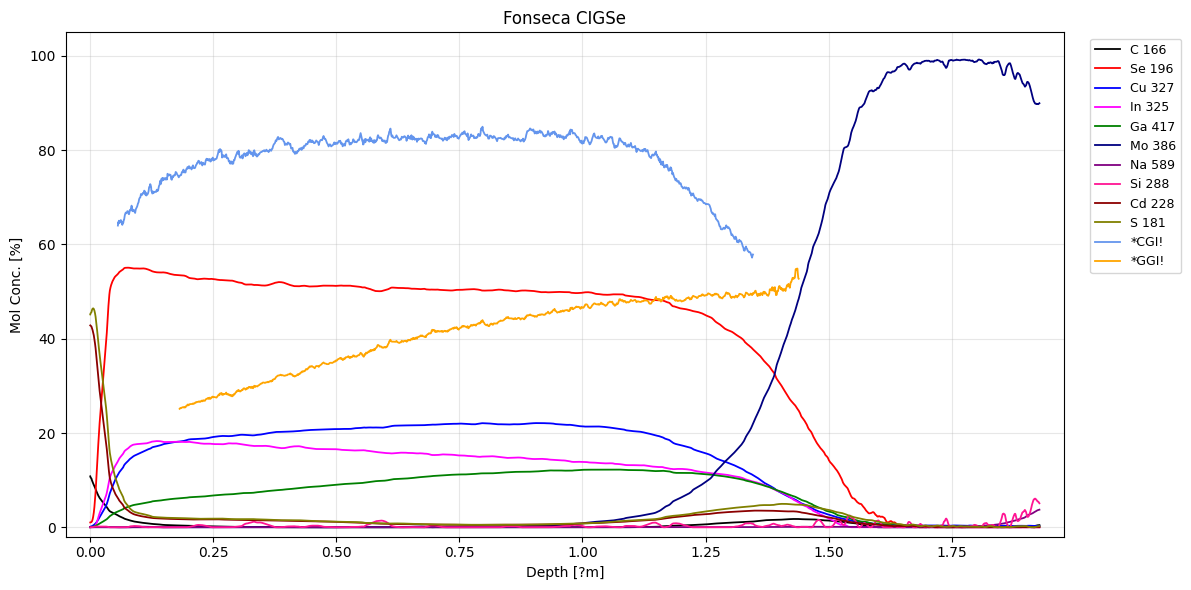

Plot saved as Fonseca CIGSe_depth_profile.png

             Max      50%       y1       y2      X1      X2  thickness [?m]
Element                                                                    
C 166    10.8065   5.4032  10.8065   5.4032  0.0001  0.0250          0.0249
Se 196   55.0723  27.5362  27.5362  27.5362  0.0232  1.4190          1.3957
Cu 327   22.1108  11.0554  11.0554  11.0554  0.0558  1.3464          1.2906
In 325   18.2939   9.1470   9.1470   9.1470  0.0371  1.3653          1.3282
Ga 417   12.2492   6.1246   6.1246   6.1246  0.1806  1.4396          1.2590
Mo 386   99.2344  49.6172  49.6172  89.9667  1.4421  1.9282          0.4861
Na 589    3.7398   1.8699   1.8699   3.7398  1.8928  1.9282          0.0354
Si 288    6.0774   3.0387   3.0387   3.0387  1.8932  1.9089          0.0157
Cd 228   42.8298  21.4149  42.8298  21.4149  0.0001  0.0280          0.0279
S 181    46.4492  23.2246  45.1584  23.2246  0.0001  0.0340          0.0339

Table saved as Fonseca CIGSe_fwhm_result

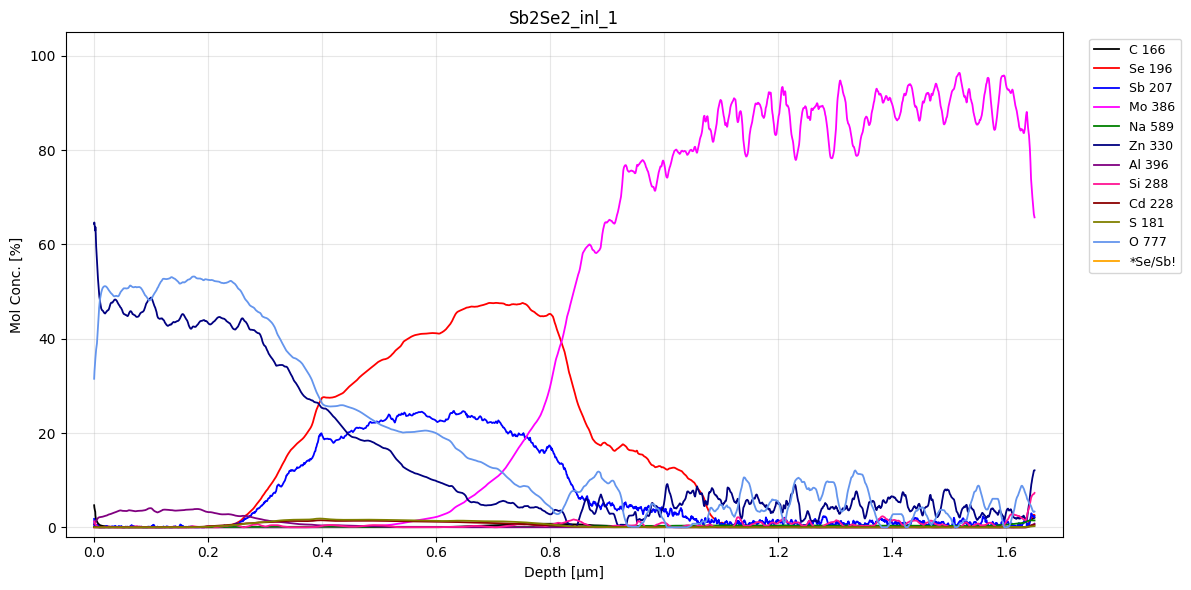

Plot saved as Sb2Se2_inl_1_depth_profile.png

            Max      50%       y1       y2      X1      X2  thickness [μm]
Element                                                                   
C 166     4.674   2.3370   4.6740   2.3370  0.0001  0.0024          0.0023
Se 196   47.610  23.8050  23.8050  23.8050  0.3873  0.8568          0.4695
Sb 207   24.690  12.3450  12.3450  12.3450  0.3543  0.8261          0.4718
Mo 386   96.400  48.2000  48.2000  65.7500  0.8376  1.6497          0.8121
Na 589    1.475   0.7375   0.7375   1.4550  1.6149  1.6497          0.0348
Zn 330   64.670  32.3350  64.3900  32.3350  0.0001  0.3457          0.3456
Al 396    4.062   2.0310   2.0310   2.0310  0.0075  0.2805          0.2730
Si 288    7.289   3.6445   3.6445   7.2890  1.6389  1.6497          0.0108
Cd 228    1.491   0.7455   0.7455   0.7455  0.2594  0.7378          0.4784
S 181     1.854   0.9270   0.9270   0.9270  0.2828  0.7666          0.4838
O 777    53.220  26.6100  31.5100  26.6100  0.0001  0.

In [11]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Elements with a peak below this threshold (mol%) are skipped in FWHM analysis
MIN_MAX_THRESHOLD = 1.0

COLORS = [
    "black", "red", "blue", "magenta", "green",
    "navy", "purple", "deeppink", "darkred", "olive", "cornflowerblue",
    "orange", "gold", "teal", "cyan", "lime",
    "indigo", "salmon", "turquoise", "brown"
]

# Substrings identifying derived ratio columns — FWHM thickness is not computed
# for these because their values are masked to the host-element layer and do not
# represent a distinct physical layer.
RATIO_SUBSTRINGS = ['GGI', 'CGI', 'Se/Sb']

## FWHM Crossing Detection

Finds the two depth positions where a signal crosses its half-maximum value using linear interpolation between adjacent data points. If only one crossing is found (e.g., the signal reaches the edge of the scan), the boundary of the measured range is used as the second boundary. Returns `None` if the signal peak is below `MIN_MAX_THRESHOLD`.

In [ ]:
def find_half_max_crossings(x, y, depth_unit):
    """
    Find the two x-positions where y crosses half-max,
    using linear interpolation for precision.
    Returns None if the signal peak is below MIN_MAX_THRESHOLD.
    """
    y_max = np.nanmax(y)
    half_max = y_max / 2.0

    if y_max < MIN_MAX_THRESHOLD or not np.isfinite(y_max):
        return None

    shifted = y - half_max

    crossings_x = []
    crossings_y = []
    for i in range(len(shifted) - 1):
        s0, s1 = shifted[i], shifted[i + 1]
        if np.isnan(s0) or np.isnan(s1):
            continue
        if s0 * s1 < 0:
            dx = x[i + 1] - x[i]
            if dx == 0:
                continue
            frac = -s0 / (s1 - s0)
            x_cross = x[i] + dx * frac
            y_cross = y[i] + (y[i + 1] - y[i]) * frac
            crossings_x.append(x_cross)
            crossings_y.append(y_cross)

    if len(crossings_x) == 0:
        return None

    if len(crossings_x) == 1:
        xc, yc = crossings_x[0], crossings_y[0]
        peak_idx = np.nanargmax(y)
        if xc < x[peak_idx]:
            x1, y1 = xc, yc
            x2, y2 = x[-1], y[-1]
        else:
            x1, y1 = x[0], y[0]
            x2, y2 = xc, yc
    else:
        x1, x2 = crossings_x[0], crossings_x[-1]
        y1, y2 = crossings_y[0], crossings_y[-1]

    return {
        "Max": round(y_max, 4),
        "50%": round(half_max, 4),
        "y1": round(y1, 4),
        "y2": round(y2, 4),
        "X1": round(x1, 4),
        "X2": round(x2, 4),
        f"thickness [{depth_unit}]": round(abs(x2 - x1), 4),
    }

## File Processing

Loads a GDOES `.txt` file, masks derived ratio columns (GGI, CGI, Se/Sb) to their relevant host-element layer, plots the full depth profile, computes FWHM for all element columns, and exports the results.

**Derived ratio masking:**
- **GGI** (Ga/(Ga+In)): masked where Ga < 50% of its peak — only meaningful within the CIGS absorber layer
- **CGI** (Cu/(Ga+In)): masked where Cu < 50% of its peak — same rationale
- **Se/Sb**: masked where Sb < 50% of its peak — only meaningful within the Sb₂Se₃ layer

In [ ]:
def process_file(filepath):
    basename = os.path.splitext(os.path.basename(filepath))[0]
    print(f"\n{'='*70}")
    print(f"  Processing: {filepath}")
    print(f"{'='*70}")

    # ── Load data ─────────────────────────────────────────────────────────
    with open(filepath) as f:
        _meta = f.readline()
        header_line = f.readline()

    col_names = [c.strip() for c in header_line.strip().split("\t")]

    raw = pd.read_csv(
        filepath, sep="\t", skiprows=2, header=None,
        na_values=["-nan(ind)", "nan", "NaN", "-nan"],
    )
    raw = raw.dropna(axis=1, how="all")
    raw.columns = col_names[: raw.shape[1]]

    depth_col = col_names[0]
    element_cols = list(raw.columns[1:])

    # Extract depth unit from column name (e.g. "Depth [$\mu$m]" → "$\mu$m")
    depth_unit = r"$\mu$m"
    if "[" in depth_col and "]" in depth_col:
        depth_unit = depth_col.split("[")[1].split("]")[0].strip()

    depth = pd.to_numeric(raw[depth_col], errors="coerce").values
    elements = {
        col: pd.to_numeric(raw[col], errors="coerce").fillna(0).values
        for col in element_cols
    }

    sort_idx = np.argsort(depth)
    depth = depth[sort_idx]

    # Pre-locate host columns for ratio masking (None if not present in this file)
    ga_col = next((x for x in element_cols if 'Ga' in x and 'GGI' not in x and 'CGI' not in x), None)
    cu_col = next((x for x in element_cols if 'Cu' in x and 'CGI' not in x), None)
    sb_col = next((x for x in element_cols if 'Sb' in x and 'Se/Sb' not in x), None)

    for col in element_cols:
        elements[col] = elements[col][sort_idx]

        # Mask GGI values outside the CIGSe layer (requires Ga column)
        if 'GGI' in col:
            if ga_col is not None:
                elements[col][elements[ga_col] < elements[ga_col].max() / 2] = np.nan
            else:
                print(f"  Warning: 'GGI' column found but no Ga column — skipping mask for {col}")

        # Mask CGI values outside the CIGSe layer (requires Cu column)
        if 'CGI' in col:
            if cu_col is not None:
                elements[col][elements[cu_col] < elements[cu_col].max() / 2] = np.nan
            else:
                print(f"  Warning: 'CGI' column found but no Cu column — skipping mask for {col}")

        # Mask Se/Sb values outside the Sb2Se3 layer (requires Sb column)
        if 'Se/Sb' in col:
            if sb_col is not None:
                elements[col][elements[sb_col] < elements[sb_col].max() / 2] = np.nan
            else:
                print(f"  Warning: 'Se/Sb' column found but no Sb column — skipping mask for {col}")

    print(f"Loaded {len(depth)} points, {len(element_cols)} columns.")
    print(f"Depth range: {depth.min():.4f} – {depth.max():.4f} {depth_unit}")
    print(f"Columns: {', '.join(element_cols)}")

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, col in enumerate(element_cols):
        ax.plot(depth, elements[col], label=col,
                color=COLORS[i % len(COLORS)], linewidth=1.3)

    ax.set_xlabel(depth_col)
    ax.set_ylabel("Mol Conc. [%]")
    ax.set_title(basename)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9, frameon=True)
    ax.set_xlim(depth.min() - 0.05, depth.max() + 0.05)
    ax.set_ylim(-2, 105)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    png_file = f"{basename}_depth_profile.png"
    plt.savefig(png_file, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved as {png_file}")

    # ── FWHM calculation ──────────────────────────────────────────────────
    results = {}

    for col in element_cols:
        if not any(r in col for r in RATIO_SUBSTRINGS):
            res = find_half_max_crossings(depth, elements[col], depth_unit)
            if res is not None:
                results[col] = res
            else:
                ymax = np.nanmax(elements[col])
                results[col] = {
                    "Max": round(ymax, 4) if np.isfinite(ymax) else ymax,
                    "50%": round(ymax / 2, 4) if np.isfinite(ymax) else ymax,
                    "y1": None, "y2": None,
                    "X1": None, "X2": None,
                    f"thickness [{depth_unit}]": None,
                }

    df_results = pd.DataFrame(results).T
    df_results.index.name = "Element"

    print(f"\n{df_results.to_string()}\n")

    xlsx_file = f"{basename}_fwhm_results.xlsx"
    df_results.to_excel(xlsx_file)
    print(f"Table saved as {xlsx_file}")

## Run Analysis

Finds all `.txt` files in the working directory and processes them sequentially. Each file produces a depth profile plot and an FWHM results table.

In [ ]:
txt_files = sorted([f for f in glob.glob("*.txt")
                    if not f.endswith("_fwhm_results.txt")])
if not txt_files:
    print("No .txt files found in the current directory.")
else:
    print(f"Found {len(txt_files)} .txt file(s): {txt_files}")
    for f in txt_files:
        process_file(f)
    print(f"\n{'='*70}")
    print("All done!")
    print(f"{'='*70}")